In [17]:
import warnings

import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

from src.data_preprocessing import processed_data_fitting
import dask.dataframe as dd

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.naive import NaiveForecaster
from sktime.utils.plotting import plot_series
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.arima import ARIMA
from sktime.forecasting.arima import AutoARIMA

mape = MeanAbsolutePercentageError(symmetric=False)

# hide warnings
warnings.filterwarnings("ignore")

In [2]:
# Importing dataset
df_train = pd.read_csv("../data/cleaned/GlobalTemperaturesCleanedTrain.csv", sep = ",", index_col = "Time")
df_test = pd.read_csv("../data/cleaned/GlobalTemperaturesCleanedTest.csv", sep = ",", index_col = "Time")

In [3]:
# Processing dataset
df_train = processed_data_fitting(df_train, "GlobalTemperaturesProcessedTrain")
df_test = processed_data_fitting(df_test, "GlobalTemperaturesProcessedTest")


In [4]:
# specifying forecasting horizon
fh = ForecastingHorizon(df_test.index, is_relative=False)
fh

ForecastingHorizon(['1973-01', '1973-02', '1973-03', '1973-04', '1973-05', '1973-06',
             '1973-07', '1973-08', '1973-09', '1973-10',
             ...
             '2015-03', '2015-04', '2015-05', '2015-06', '2015-07', '2015-08',
             '2015-09', '2015-10', '2015-11', '2015-12'],
            dtype='period[M]', name='Time', length=516, is_relative=False)

## Naive

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='LandAverageTemperature'>)

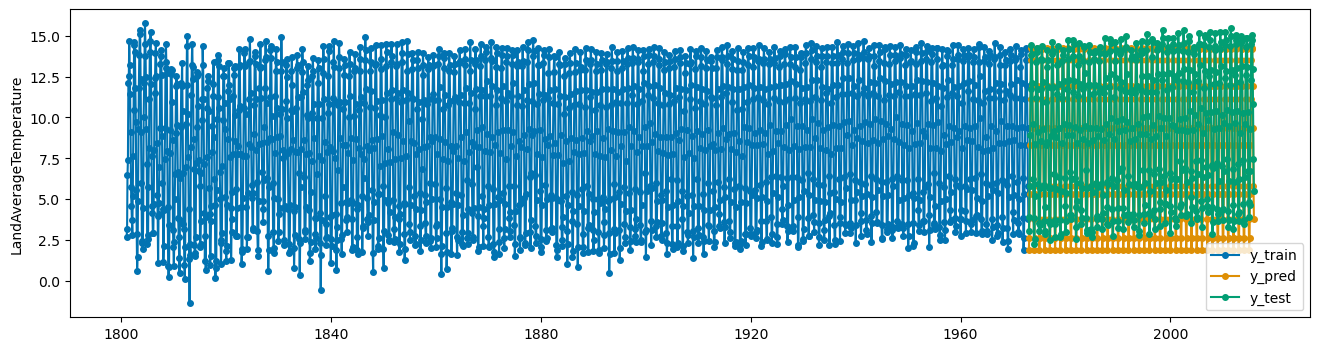

In [5]:
# specifying the forecasting algorithm
naive_forecaster = NaiveForecaster(strategy="last", sp=12) 

# fitting the forecaster
naive_forecaster.fit(df_train)

# querying predictions
y_pred_naive = naive_forecaster.predict(fh)

# plot predictions
plot_series(df_train, y_pred_naive, df_test, labels=["y_train", "y_pred", "y_test"])

In [ ]:
mape(df_test, y_pred_naive)

0.11602004596444404

# ETS

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='LandAverageTemperature'>)

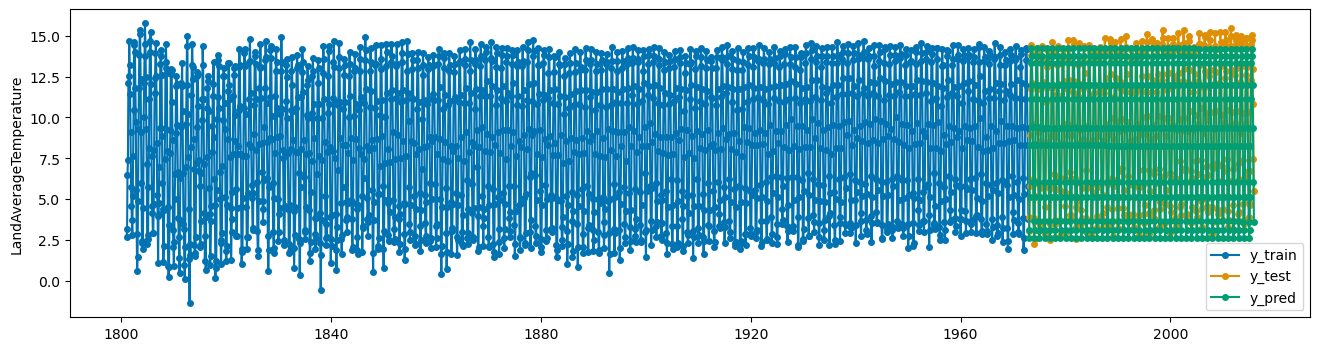

In [10]:
forecaster_exp = ExponentialSmoothing(trend="add", seasonal="additive", sp=12)
forecaster_exp.fit(df_train)
y_pred_exp = forecaster_exp.predict(fh)
plot_series(df_train, df_test, y_pred_exp, labels=["y_train", "y_test", "y_pred"])

In [11]:
mape(df_test, y_pred_exp)

0.09336951069126367

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='LandAverageTemperature'>)

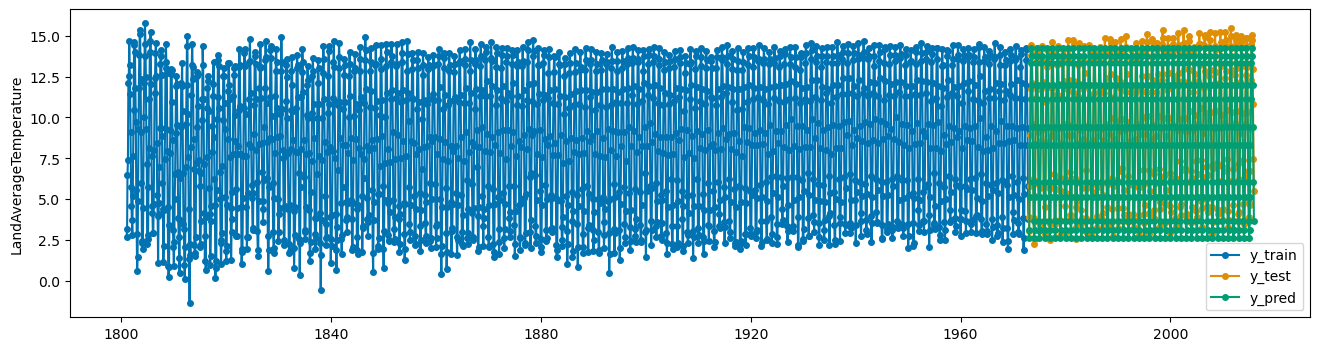

In [12]:
forecaster_ets = AutoETS(auto=True, sp=12, n_jobs=-1)
forecaster_ets.fit(df_train)
y_pred_ets = forecaster_ets.predict(fh)
plot_series(df_train, df_test, y_pred_ets, labels=["y_train", "y_test", "y_pred"])

In [14]:
# Parameters of ets
parameters_ets = forecaster_ets.get_fitted_params(deep=True)
parameters_ets

{'aic': 3352.940656844567,
 'aicc': 3353.206411607635,
 'bic': 3443.05907487019,
 'hqic': 3385.9775365655846}

In [26]:
mape(df_test, y_pred_ets)

0.09214673076244896

## ARIMA

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='LandAverageTemperature'>)

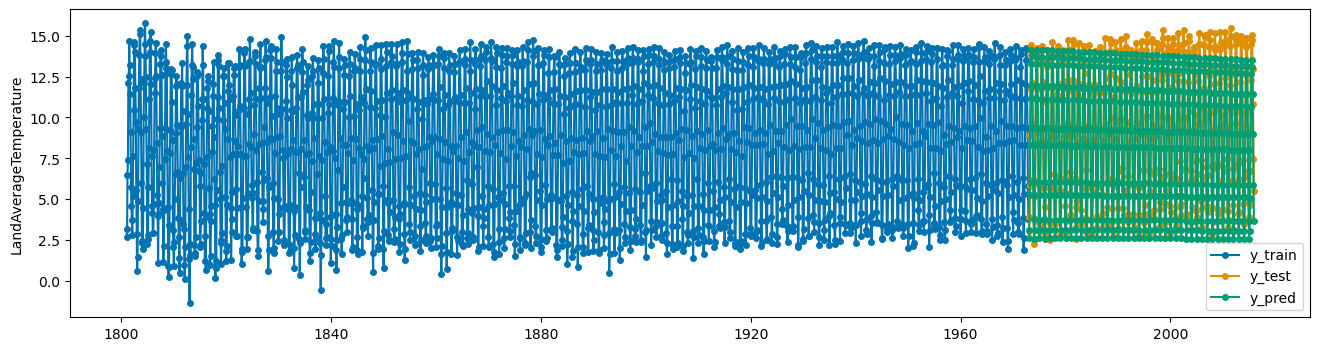

In [5]:
forecaster_arima = AutoARIMA(sp=12, suppress_warnings=True)

forecaster_arima.fit(df_train)
y_pred_arima = forecaster_arima.predict(fh)
plot_series(df_train, df_test, y_pred_arima, labels=["y_train", "y_test", "y_pred"])


In [13]:
# Parameters of arima
parameters_arima = forecaster_arima.get_fitted_params(deep=True)
parameters_arima

{'intercept': -6.61373182066028e-06,
 'ar.L1': 0.41526598445260055,
 'ma.L1': -1.057503221918567,
 'ma.L2': 0.09693860392258039,
 'ar.S.L12': 0.13258870874912987,
 'ar.S.L24': 0.8649346608922721,
 'ma.S.L12': -0.004804082532508112,
 'ma.S.L24': -0.7222118460773107,
 'sigma2': 0.28768739204670946,
 'order': (1, 1, 2),
 'seasonal_order': (2, 0, 2, 12),
 'aic': 3363.1621196367723,
 'aicc': 3363.249796207644,
 'bic': 3413.8493682544135,
 'hqic': 3381.744221547189}

In [15]:
mape(df_test, y_pred_arima)

0.10430388993811315

evaluate using MAPE and RMSE